# Prioritizing Editorial Review: A Data-Driven Content Queue

> **Abstract:** A scoring system for prioritizing content refresh combines
> a page's decline severity with its predicted probability of recovering
> without intervention. To estimate that probability, a random forest was
> trained on daily search performance records from a FlyRank data warehouse,
> reaching an AUC of 0.71 and a 29–31 percentage-point precision lift over
> base-rate guessing on held-out clients (5-fold, client-grouped
> cross-validation). The final feature set was chosen after testing PCA
> and Elastic Net methods to resolve a multicollinearity problem. Elastic Net
> was selected for matching the strongest performance while keeping every
> feature individually interpretable. The result is a ranked queue with
> plain-language reason codes; Most pages fall into
> high-impact/low-recovery, the top-priority category. A smaller set of
> high-impact/likely-recovers pages illustrate why the queue is meant to
> support editorial judgment, not replace it.

## 1. Introduction

Content teams manage far more pages than they can review individually. An editor can discover pages declining in traffic from Google Search Console. However, that method poses a problem: Nothing about the page suggests whether or not a page will recover without intervention. A page can appear to be declining but is actually experiencing a temporary fluctuation that reverses within weeks. A raw "fix biggest drops first" ignores recovery potential, which means an editor's limited
time is as likely to be spent on a page that would have fixed itself as
on one that genuinely needs help.

Distinguishing decline severity from recovery potential is not something a static ranking can do; it requires learning from real historical outcomes to predict whether a declining page can bounce back. This project builds a score by combining how much is at stake for a page with how likely it is to
recover without help. The goal of the scoring system is to help editors prioritize declining pages that are more likely to benefit from human intervention, not toward ones that are more likely to resolve on their own.

## 2. Data

The data used is the FlyRank internship warehouse dataset, specifically
`fact_content_daily_performance` (daily impressions/clicks/position) and
`dim_content` (static content attributes). A cutoff T = 2026-02-01 was
chosen by scanning every candidate month for the one maximizing clients
with both sufficient feature history and label runway (39 eligible
clients resulted).

Each row represents one content item, for one client, as of T. Only
pages already declining at T (impressions falling more than 20% over 30
days) are used in training. The label, `recovered_by_T1`, is whether that
page's impressions rose again in the following 30-day window.

Features included cover a page's current visibility (search position,
impressions, clicks), content characteristics (char count, content type, intent), and time since the page was last updated or created.

The following features were excluded from model input:
- `trend_pct`/`trend_direction` - label-derived, used only to define the
  decline gate itself.
- `is_deleted`, `is_published` - current-snapshot fields with risk of
  reflecting post-T state rather than state as of T.
- `last_optimized_date` - "was this page optimized" and "did this page
  recover" are plausibly the same event; using it would risk leakage.
- `client_hash_id`/`content_hash_id` - used only for joins and
  cross-validation grouping.

Client and content identifiers are pseudonymized (pre-hashed) by the
data source; no client names, domains, URLs, or private queries appear
anywhere in this repo.

## 3. Methodology

### Scoring
The scoring formula used was `score = impact_at_risk x unlikeliness_to_recover` = `impact_at_risk x (1 - probability_of_recovery)`. The baseline used `avg_position` as an untested proxy for recovery likelihood while the model used the prediction result based on historical outcomes.

### Baseline
The resulting ranked queue consisted of 4 of its top 20 picks labelled with low_decline yet outranked high_decline picks. 2 top picks had fewer than 10 clicks despite ranking high on impressions alone. Both weaknesses motivated replacing the untested avg_position recovery-proxy with a trained, validated probability.

### Modeling
Both logistic regression and random forest were tested. To properly compare the two methods, 5-fold cross validation was used, ensuring fair client training/validation splits and no repeat clients. The average AUC/Precision@20/Precision@50 values across all folds were used to compare model quality.

Features were deliberately chosen (see section 2). The recovery label windows and feature windows were strictly separated by the cutoff T and never overlapped. The label recovered_by_T1 represents an increase in impressions from one 30d period to the next after T. This was the label used to compare to the prediction model responses to calculate precision values.

After checking for multicollinearity, multiple correlated features were discovered. In particular, a cluster of model_used, char_count, char_count_imputed, and ai_generated correlated with each other, dominating the model's coefficients. PCA compressed the confound cluster into orthogonal components before model fitting, resolving the correlation directly in the feature space. Elastic Net resolved the same correlation during model fitting rather than beforehand. Both PCA and Elastic Net improved the model slightly. Elastic Net was selected as the final feature selection method because it handled correlated predictors directly with similar performance without requiring PCA's feature-blending complexity.

For the final feature set, the random forest max depth was tuned via grid search. Additionally, residual-correction boosting was tested on both final models. Random forest showed no meaningful benefit while logistic regression showed a modest benefit. Given the added model complexity without a real performance gain, boosting was not adopted for the final model.


## 4. Results

The hand rule baseline was built and evaluated on the starter CSV (a
single 90-day snapshot, no forward-looking outcome available). The CSV
also has no `recovered_by_T1` label, so the baseline was never validated
against recovery. However, the baseline's ranked queue had weaknesses on
its own terms: 4 of its top 20 picks were labeled `low_decline` yet
outranked `high_decline` picks, and 2 top picks had fewer than 10 clicks
despite ranking high on impressions alone.

Instead, for precision comparison, we use the base rate — the fraction
of pages that would count as "correct" from picking at random, given
each fold's own natural mix of recovered vs. stayed-broken pages. Lift
subtracts out that base-rate effect: an average lift of 0.29–0.31 means
the model's top picks beat random guessing by roughly 29–31 percentage
points, after accounting for how easy or hard each fold's base rate
already made the task. For AUC, the reference point is 0.5 — the value a
model gets by guessing randomly.

| | Full features | Final model |
|---|:---:|:---:|
| AUC | 0.684 | 0.708 |
| Precision@20 | 0.890 | 0.890 |
| Precision@50 | 0.892 | 0.916 |
| Precision@20 lift over base rate | 0.292 | 0.292 |
| Precision@50 lift over base rate | 0.294 | 0.314 |
Figure 1: Original vs Final random forest model performance statistics

In [4]:
from IPython.display import Image, display
display(Image(f"../outputs/ml10_precision_vs_baserate.png"))
print("Figure 2: Precision vs Base Rate")

FileNotFoundError: No such file or directory: '../outputs/ml10_precision_vs_baserate.png'

FileNotFoundError: No such file or directory: '../outputs/ml10_precision_vs_baserate.png'

<IPython.core.display.Image object>

For addressing multicollinearity, Elastic Net was selected as final because it matched or exceeded every
other method's AUC while keeping every feature individually named — no
transform objects to persist for scoring, and no PCA loadings table
needed to interpret what a feature represents.

In [5]:
from IPython.display import Image, display
display(Image(f"../outputs/ml10_method_comparison.png"))
print("Figure 3: Feature reduction results (AUC)")
display(Image(f"../outputs/ml10_method_comparison2.png"))
print("Figure 2: Feature reduction results (Precision)")

FileNotFoundError: No such file or directory: '../outputs/ml10_method_comparison.png'

FileNotFoundError: No such file or directory: '../outputs/ml10_method_comparison.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '../outputs/ml10_method_comparison2.png'

FileNotFoundError: No such file or directory: '../outputs/ml10_method_comparison2.png'

<IPython.core.display.Image object>

The most consistently significant
feature across every variant tested, by a wide margin, is
`days_since_last_update` — negative and stable whether the confound
cluster is present or removed, strengthening (not weakening) as
correlated noise is removed, which is the strongest evidence in this
analysis that its effect is real rather than an artifact. [Add the next
2-3 features from `results_final["coef_summary"]` or
`feature_importances_`, e.g. `gsc_avg_position`, `days_since_created`,
`has_keyword_data`.] Full ranked importances are available in the
underlying notebook (`w05_model.ipynb`).

In [ ]:
from IPython.display import Image, display
# "ml10_score_distribution.png"
display(Image(f"../outputs/ml10_feature_importance.png"))
print("Figure 4: Feature importance of final model")

## 5. Limitations

No causal claim can be made that reviewing a flagged page causes recovery — this analysis is observational, no controlled comparison exists between refreshed and non-refreshed pages. The model identifies pages worth a human review, not the review decision itself; never auto-remove, auto-merge, or auto-deprioritize a page based on this queue alone. An editor should read the continuous priority_score, impact_at_risk, and p_recovery values, not just the reason-code label, since the two can disagree at the margins by design.

days_since_last_update's strong, consistent coefficient likely reflects editorial attention arriving during/after a decline, not pre-existing staleness (section 2) — this changes what causal story can honestly be told about it, though it does not weaken the finding for triage purposes.

content_type's relevance to recovery is unconfirmed — recovered by manual removal and RFECV, not by Elastic Net, forward selection, Lasso, or PCA. Reported as directional, not established.

Predicted P(recovery) is measurably miscalibrated (section 4) — priority scores likely understate urgency for some mid-probability pages.

Model built on only 38–39 eligible clients; scores for very new or thin-history clients should be treated as lower confidence. Should be retrained as more client history becomes available.

This queue answers "which known problems deserve attention first," not "which healthy pages are about to decline" — a different, complementary model (predicting decline for the currently-healthy population, same pipeline structure, gate and label reversed), not built here due to scope.

## 6. Ranked recommendations

priority_score = impact_at_risk × (1 − p_recovery), with four reason codes from fixed-percentile thresholds on impact_at_risk (top quartile) and p_recovery (bottom quartile): high_impact_low_recovery (top priority), high_impact_likely_recovers (monitor), low_impact_low_recovery (low priority), low_impact_likely_recovers (no action).

An editor opens the top of the queue and, for each flagged page, checks: (1) whether the decline is real or a deindexing/retirement case the model can't distinguish, (2) whether the page's client resembles the 39 training clients — treat scores for very new/thin-history clients with lower confidence, (3) the raw impact_at_risk/p_recovery values, not just the reason-code label.

,index,client_hash_id,content_hash_id,trend_pct_at_T,p_recovery,impact_at_risk,priority_score,reason_code
0,33015,client_1d09b519bdde7c7a,content_5519ab199297bdb2,-100.000000,0.096528,0.720535,0.650983,high_impact_low_recovery
1,32113,client_861cdcccf8049915,content_4e1a6900719d2ef1,-90.620834,0.065929,0.673965,0.629531,high_impact_low_recovery
2,14913,client_861cdcccf8049915,content_eea3b2434e98edf3,-93.462165,0.060723,0.667077,0.626570,high_impact_low_recovery
3,32118,client_861cdcccf8049915,content_53031986a96b7913,-83.277013,0.078036,0.674327,0.621705,high_impact_low_recovery
4,16027,client_1d09b519bdde7c7a,content_c9a819d1b9ad7420,-99.646143,0.108741,0.627437,0.559209,high_impact_low_recovery
5,14983,client_861cdcccf8049915,content_bc2054d6c1c0cce3,-86.756423,0.079719,0.592391,0.545166,high_impact_low_recovery
6,16164,client_1d09b519bdde7c7a,content_972690231ea8c69f,-100.000000,0.089627,0.598538,0.544893,high_impact_low_recovery
7,32933,client_861cdcccf8049915,content_61e0132a1b88a72d,-79.439421,0.064600,0.566700,0.530091,high_impact_low_recovery
8,15881,client_1d09b519bdde7c7a,content_fcc1f8ce43abd284,-100.000000,0.090843,0.580758,0.528000,high_impact_low_recovery
9,33288,client_1d09b519bdde7c7a,content_84cddd3755287607,-100.000000,0.081964,0.567875,0.521329,high_impact_low_recovery


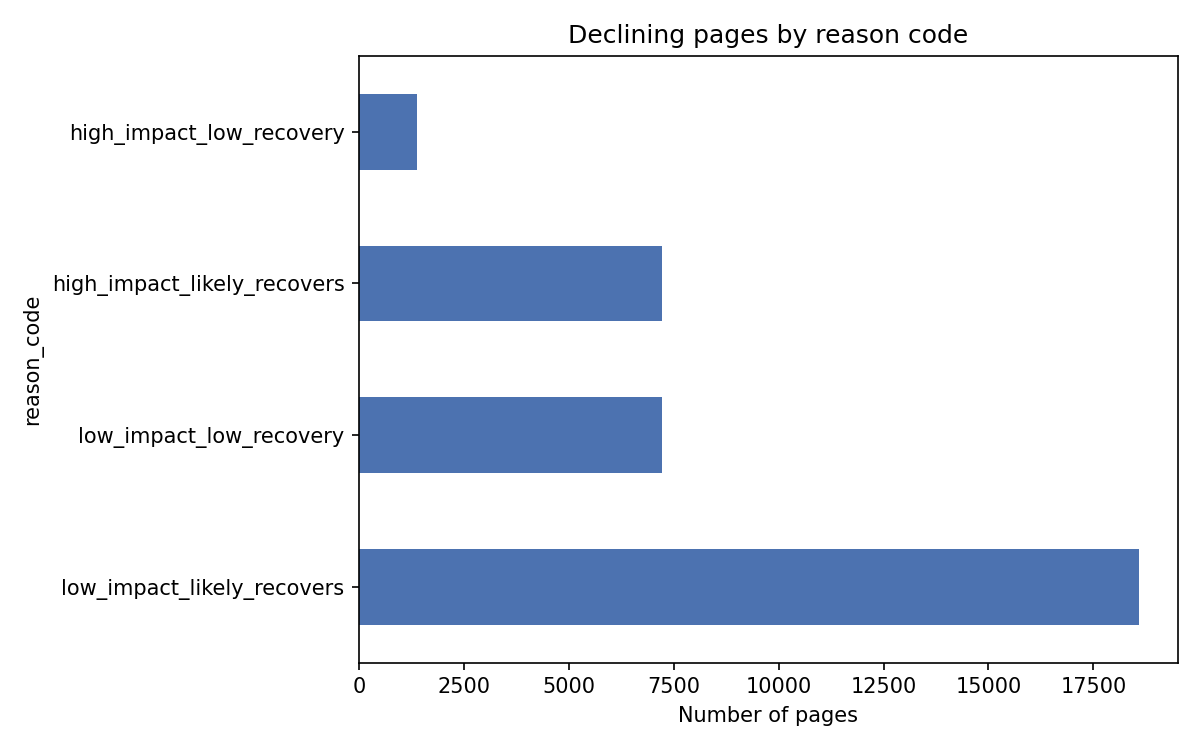

In [ ]:
#%pip install pandas
import pandas as pd

df = pd.read_csv("../outputs/ml10_top20_preview.csv")
display(df)
display(Image(filename='../outputs/ml10_reason_code_distribution.png'))

## 7. Reproducibility

Repo: https://github.com/mishellscripts/flyrank
Environment: DuckDB + Hugging Face-hosted parquet warehouse (FlyRank/internship-warehouse), accessed via Colab. Requires an HF_TOKEN Colab Secret with read access to the gated dataset.
To re-run: open work/notebooks/w05_model.ipynb, Runtime → Run all (accept the HF dataset gate in-browser first), then work/notebooks/w07_action_playbook.ipynb, then capstone.ipynb.
Seeds: random_state=33 used consistently across all model fits.
Outputs: land in work/outputs/ — ml10_action_queue.csv, ml10_summary_stats.csv, ml10_top20_preview.csv, plus the figures embedded above.

## Acknowledgements

Built on the FlyRank ML Internship dataset — https://flyrank.ai